In [19]:
%reload_ext autoreload
%autoreload 2

import matlab
from DatasetAPI import DatasetAPI
from ExtractorAPI import ExtractorAPI
from EvaluationAPI import EvaluationAPI
from FingerprintingAPI import FingerprintingAPI

In [3]:
ROOT_DIRECTORY = '/home/smazokha2016/Desktop'
MATLAB_SRC_DIRECTORY = '/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting/lora_rffi_working'
MATLAB_SESSION_ID = 'fp_workflow'

DATA_CONFIG = {
    'dataset_name': DatasetAPI.DATASET_V2,
    'frame_count_train': 200, # 200 for v2, 500 for v3
    'frame_count_epoch': 100,
    'samples_count': 400
}

AUG_CONFIG = {
    'multiplier': 5,
    't_rms_bounds': matlab.double([1, 2]),
    'd_f_bounds': matlab.double([0, 10]),
    'k_factor_bounds': matlab.double([0, 10]),
    'awgn': matlab.double([10, 50]),
}

MODEL_CONFIG = {
    'batch_size': 32,
    # 'loss_type': 'triplet_loss', 'loss_num_neg': 1,
    'loss_type': 'quadruplet_loss', 'loss_num_neg': 2,
    #  'loss_type': 'quintuplet_loss', 'loss_num_neg': 3,
    # 'loss_type': 'n_loss', 'loss_num_neg': 2,
    'npair_type': 'samedev',
    # 'npair_type': 'diffdev',
    'alpha': 1.0, # used only for triple & quadruple loss
    'patience': 10,
    'fp_len': 512,
    'row': 50,
    'col': 14
}

RX_NODES = [DatasetAPI.RX_1, DatasetAPI.RX_2, DatasetAPI.RX_3, DatasetAPI.RX_4]

In [4]:
dataset_api = DatasetAPI(root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=False)
extractor_api = ExtractorAPI()
fp_api = FingerprintingAPI(rx_ids = RX_NODES, 
                           data_config=DATA_CONFIG, aug_config=AUG_CONFIG, model_config=MODEL_CONFIG, 
                           root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=False)

## 1. Train the model

In [5]:
# models, _ = fp_api.train_models()
models = fp_api.load_models()

2024-08-29 15:56:35.392641: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 888 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:03:00.0, compute capability: 8.0
2024-08-29 15:56:35.394139: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 42407 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:04:00.0, compute capability: 8.0
2024-08-29 15:56:35.395685: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 78221 MB memory:  -> device: 2, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:43:00.0, compute capability: 8.0


In [6]:
eval_api = EvaluationAPI(rx_ids = RX_NODES, models = models, data_config=DATA_CONFIG, aug_config=AUG_CONFIG, model_config=MODEL_CONFIG, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=False)

## 1.1. Prepare a method that will give signal for testing the system

Input:
* epoch number (1-based)
* device name (important: this is NOT an index)
* number of frames

In [84]:
grid_node_ids, grid_node_coordinates = eval_api.generate_grid_node_ids()

dataset_train_path, dataset_epoch_paths, model_path, node_ids_train, node_ids_epoch, samp_rate = dataset_api.load_dataset_info(DATA_CONFIG['dataset_name'], DatasetAPI.RX_1, None)

node_ids_epoch

[1, 10, 20, 39, 239, 269, 280, 300, 315, 330, 394, 398]

## 2. Enroll our first device

Input:
- a list of frame objects, each of them contains:
    - list of IQ frames (corresponding to a preamble)
    - RSSI value

The algorithm:
Note: keep in mind which RX devices we're working with
1. Initialize a list of device candidates
2. For each receiver:
    1. For each of the frames:
        1. Pick a specified # of samples, optionally apply awgn
        2. Extract fingerprints for each frame
        3. Transform RSSI into a weight
        4. Extract a fingerprint
    2. Aggregate all frames into one input (either average weights & FPs, or pick one of them)
    3. Look up devices from ChromaDB
    4. Do we have any finds:
        1. Yes: add top K neighbors to our candidate list, assign a receiver-specific rank
        2. No:  do nothing
3. For each candidate:
    1. Retrieve fingerprints (vectors) across all receivers
    2. Calculate device candidate weighted distance to our frame
4. Are all distances above the threshold? (or any distances at all)
    1. Yes: this is a new device. Add the corresponding fingerprints to receiver collections
    2. No:  this is a known device. It corresponds to the candidate with the smallest weighted distance
5. Return a dictionary containing candidate metrics

Additional TODOs:
* Implement a function that can give us a selection of device frames to use for testing, make it part of the DatasetAPI module
* Implement ChromaDB integration (we need to create / connect to a collection, etc)
* Augment the constructor to provide a threshold

In [85]:
frames = dataset_api.load_testing_input(dataset_epoch_paths, 10, 269, 10)
fp_api.new_signal(frames, new_device_threshold=0.55)

1/1 [==============================] - 0s 25ms/step


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


1/1 [==============================] - 0s 24ms/step


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


1/1 [==============================] - 0s 24ms/step


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


1/1 [==============================] - 0s 24ms/step


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


This is a new device. New ID: c9c26891-10ee-43c5-a605-3da2cd9d2314


Total number of unique devices: 2

Device Statistics:
Device ID: c9c26891-10ee-43c5-a605-3da2cd9d2314 (added: 2024-08-29T17:46:57.347494, last updated: Not updated)
Device ID: ee1abaf8-e0cf-4993-95b0-936b30e0488a (added: 2024-08-29T17:42:41.312552, last updated: 2024-08-29T17:46:18.588596)


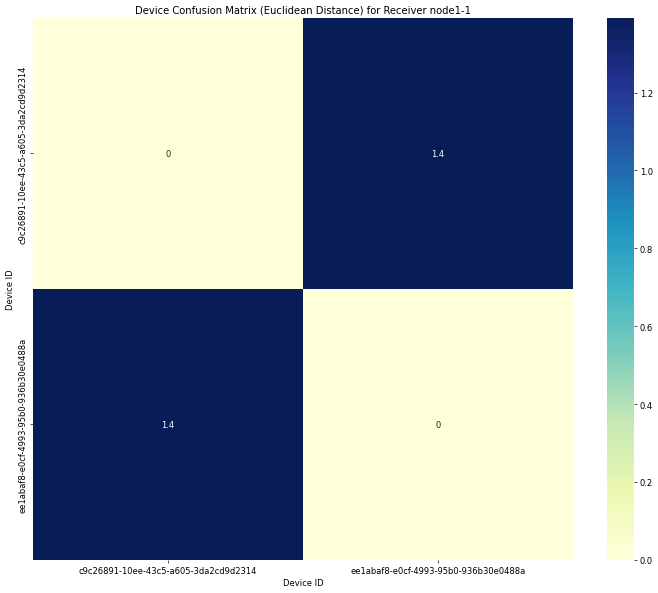

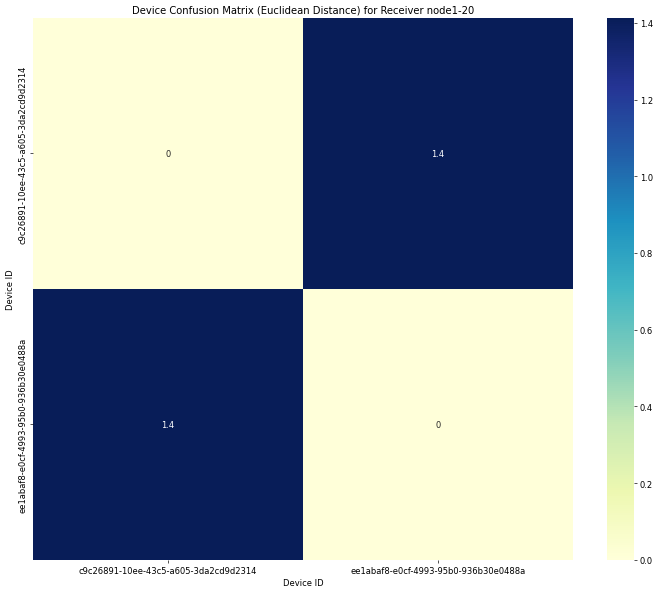

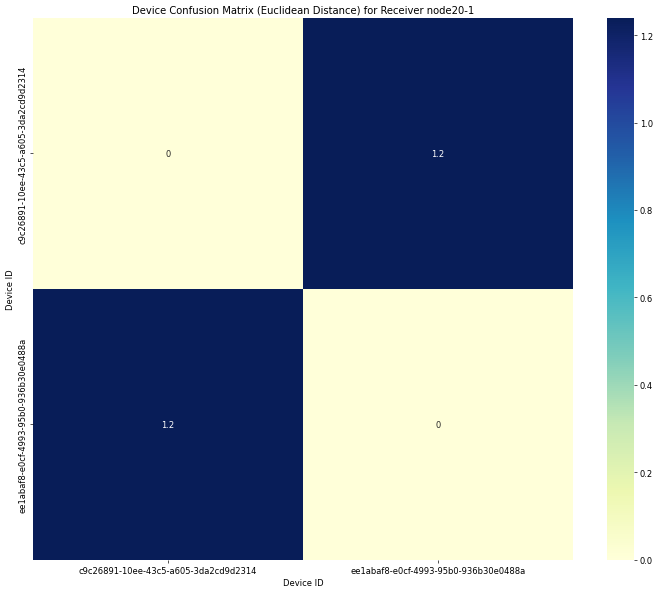

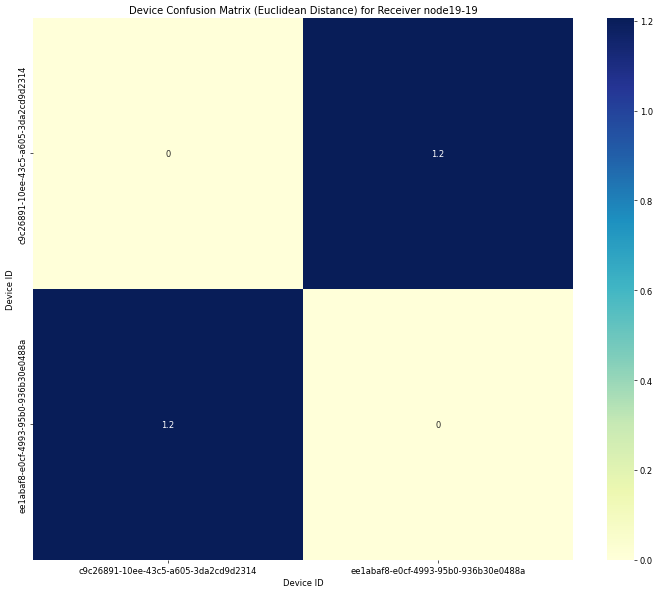

In [99]:
enrolled_devices = fp_api.list_enrolled_devices(render_confusion_matrices=True)

In [95]:
enrolled_devices['c9c26891-10ee-43c5-a605-3da2cd9d2314']['embeddings'].keys()

dict_keys(['node1-1', 'node1-20', 'node20-1', 'node19-19'])

In [71]:
fp_api.purge_database()